In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Loading Dataset

In [2]:
df = pd.read_csv("./traces.csv")
df.head()

,event_id,event_type,timestamp,run_id,sequence_number,agent_role,tool_name,tool_input,tool_output,prompt,...,memory_mb,goroutines,model_name,cost_usd,error_type,error_message,retry_count,queue_wait_ms,tokens_per_second,cache_hit
0,run-0000-evt-0001,run_started,2026-03-31T13:55:45.619011+08:00,run-0000,1,NaN,NaN,NaN,NaN,NaN,...,9.58,9,NaN,0.0,NaN,NaN,0,0,0.0,False
1,run-0000-evt-0002,agent_invoked,2026-03-31T13:55:45.619565+08:00,run-0000,2,supervisor,NaN,NaN,NaN,NaN,...,9.58,9,NaN,0.0,NaN,NaN,0,0,0.0,False
2,run-0001-evt-0001,run_started,2026-03-31T13:55:45.61906+08:00,run-0001,1,NaN,NaN,NaN,NaN,NaN,...,9.59,8,NaN,0.0,NaN,NaN,0,0,0.0,False
3,run-0001-evt-0002,agent_invoked,2026-03-31T13:55:45.61987+08:00,run-0001,2,supervisor,NaN,NaN,NaN,NaN,...,9.59,8,NaN,0.0,NaN,NaN,0,0,0.0,False
4,run-0002-evt-0001,run_started,2026-03-31T13:55:45.619039+08:00,run-0002,1,NaN,NaN,NaN,NaN,NaN,...,9.60,8,NaN,0.0,NaN,NaN,0,0,0.0,False


### Descriptive Statistics

In [3]:
print("1. =====DATAFRAME DESCRIBE=====")
print(df.describe())
print("\n\n\n2. =====EVENT TYPES=====")
print(df['event_type'].value_counts())
print("\n\n\n3. =====BULK OF LATENCY DESCRIBE=====")
print(df[(df["latency_ms"] > 500) & (df["latency_ms"] < 8000)]["latency_ms"].dropna().describe())

1. =====DATAFRAME DESCRIBE=====
       sequence_number  input_tokens  output_tokens    latency_ms  \
count       2033.00000   2033.000000    2033.000000   2033.000000   
mean          21.12543     40.651254     139.867191   1490.986719   
std           12.05044     87.163192     213.970326   3798.784634   
min            1.00000      0.000000       0.000000      0.000000   
25%           11.00000      0.000000       0.000000      0.000000   
50%           21.00000      0.000000       0.000000      0.000000   
75%           32.00000     55.000000     366.000000   3135.000000   
max           47.00000    710.000000     512.000000  41706.000000   

       execution_ns  cpu_percent    memory_mb   goroutines     cost_usd  \
count  2.033000e+03  2033.000000  2033.000000  2033.000000  2033.000000   
mean   1.213066e+09    14.832868     7.687068    11.859321     0.000185   
std    4.541597e+09     1.042422     1.999945     0.834117     0.000282   
min    3.670900e+04    10.030000     4.120000 

### Descriptive Statistics Analysis

1. Using describe on the whole dataframe presents data that is "zero-heavy"; therefore, need more conclusive details on what ranges we actually want to sample.  Finding the core feature we need to focus upon is the largest issue at hand, so we can look towards other methods, graphs, and charts for leading us to the answers.
2. When observing our event types, we can see the majority of our events lie within: llm_request_sent, llm_response_received, agent_invoked, agent_completed, message_sent, tool_called, tool_returned, routing_decided.  The fours categories outstanding are: run_started, run_completed, retry_started, error_occurred, which may be important in an operations sense; however, here they are considered noice, so those are our first candidates to be dropped.
3. While doing an analysis of the data the sequence of (500, 8000) stuck out as the best range to view the majority of data.  Subsequently, we wouldn't want to drop this data intially since some events may take place outside of the range, which may be important to latency, execution time, and overall agentic ai performance.  With a max of 6783ms and a min of 902ms, with a standard deviation of 944ms but a mean of 3679ms, the majority of our data with be right-skewed when viewing the "primetime" window.  Therefore, to get somewhat of a better picture 3000-5000ms might be a much better sequence to observe, so we will conduct further investigation to find where our data lies within the context of event types.

### Visualizations

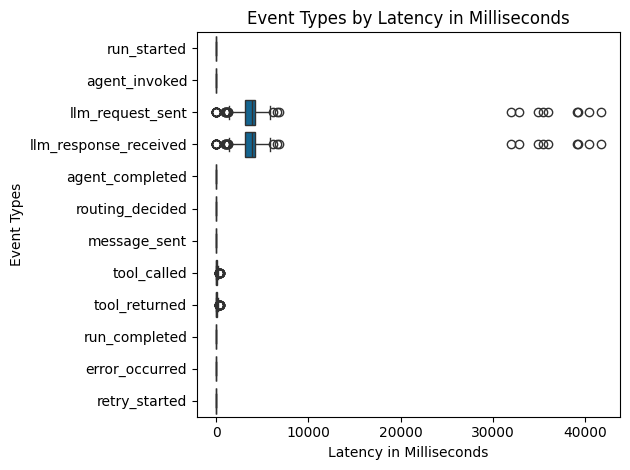

In [27]:
plt.style.use('tableau-colorblind10')
ax = sns.boxplot(data=df, x='latency_ms', y='event_type')
ax.set_title("Event Types by Latency in Milliseconds")
ax.set_xlabel("Latency in Milliseconds")
ax.set_ylabel("Event Types")
plt.tight_layout()
plt.show()

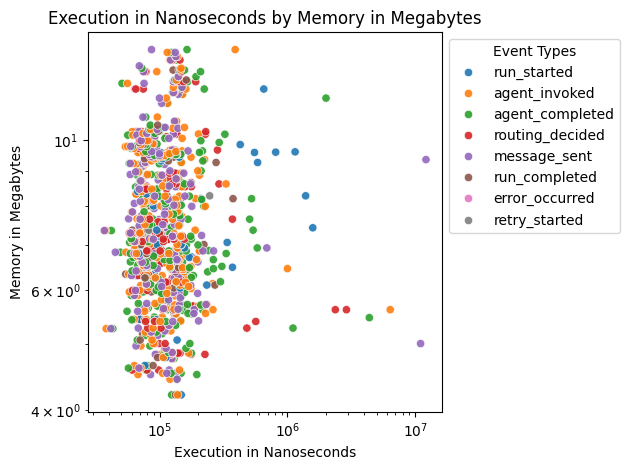

In [5]:
# blacklist events as noise
events_excluded = ["run_started", "agent_completed", "run_completed", "routing_decided", "message_sent", "error_occurred", "retry_started", "agent_invoked"]
latency_df = df[
    df['event_type'].isin(events_excluded)
]

ax = sns.scatterplot(
    data=latency_df,
    x="execution_ns",
    y="memory_mb",
    hue="event_type",
    alpha=0.9
)

# apply log since values are in seperate SI units (ns vs ms)
plt.xscale("log")
plt.yscale("log")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Event Types")

ax.set_title("Execution in Nanoseconds by Memory in Megabytes")
ax.set_xlabel("Execution in Nanoseconds")
ax.set_ylabel("Memory in Megabytes")
plt.tight_layout()
plt.show()

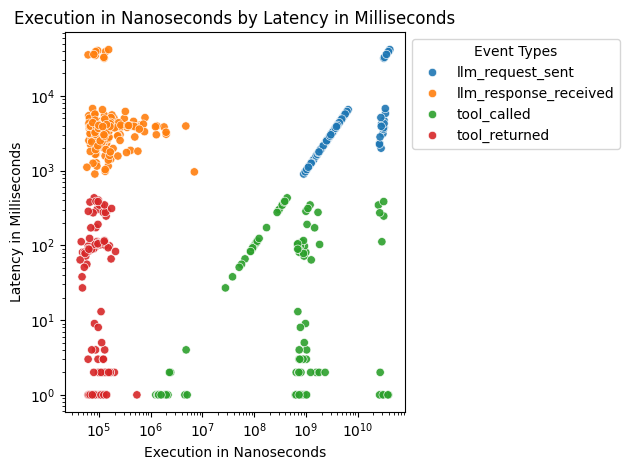

In [6]:
# blacklist events as noise
events_excluded = ["run_started", "agent_completed", "run_completed", "routing_decided", "message_sent", "error_occurred", "retry_started", "agent_invoked"]
latency_df = df[
    ~df['event_type'].isin(events_excluded)
]

ax = sns.scatterplot(
    data=latency_df,
    x="execution_ns",
    y="latency_ms",
    hue="event_type",
    alpha=0.9
)

# apply log since values are in seperate SI units (ns vs ms)
plt.xscale("log")
plt.yscale("log")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Event Types")

ax.set_title("Execution in Nanoseconds by Latency in Milliseconds")
ax.set_xlabel("Execution in Nanoseconds")
ax.set_ylabel("Latency in Milliseconds")
plt.tight_layout()
plt.show()

[Text(0.5, 0, '(0.999, 1.873]'),
 Text(2.5, 0, '(2.0, 3.0]'),
 Text(4.5, 0, '(4.315, 6.553]'),
 Text(6.5, 0, '(8.72, 12.69]'),
 Text(8.5, 0, '(27.0, 38.0]'),
 Text(10.5, 0, '(51.0, 56.0]'),
 Text(12.5, 0, '(64.0, 66.825]'),
 Text(14.5, 0, '(74.04, 79.628]'),
 Text(16.5, 0, '(82.895, 84.0]'),
 Text(18.5, 0, '(89.0, 90.0]'),
 Text(20.5, 0, '(91.325, 93.365]'),
 Text(22.5, 0, '(94.568, 97.31]'),
 Text(24.5, 0, '(98.973, 100.0]'),
 Text(26.5, 0, '(102.0, 103.0]'),
 Text(28.5, 0, '(105.0, 107.375]'),
 Text(30.5, 0, '(110.185, 111.795]'),
 Text(32.5, 0, '(112.998, 114.0]'),
 Text(34.5, 0, '(116.0, 124.0]'),
 Text(36.5, 0, '(172.0, 173.18]'),
 Text(38.5, 0, '(202.9, 257.79]'),
 Text(40.5, 0, '(274.852, 276.82]'),
 Text(42.5, 0, '(286.0, 291.0]'),
 Text(44.5, 0, '(302.0, 312.0]'),
 Text(46.5, 0, '(341.0, 344.07]'),
 Text(48.5, 0, '(346.238, 347.44]'),
 Text(50.5, 0, '(366.632, 379.535]'),
 Text(52.5, 0, '(386.0, 389.0]'),
 Text(54.5, 0, '(404.0, 433.0]')]

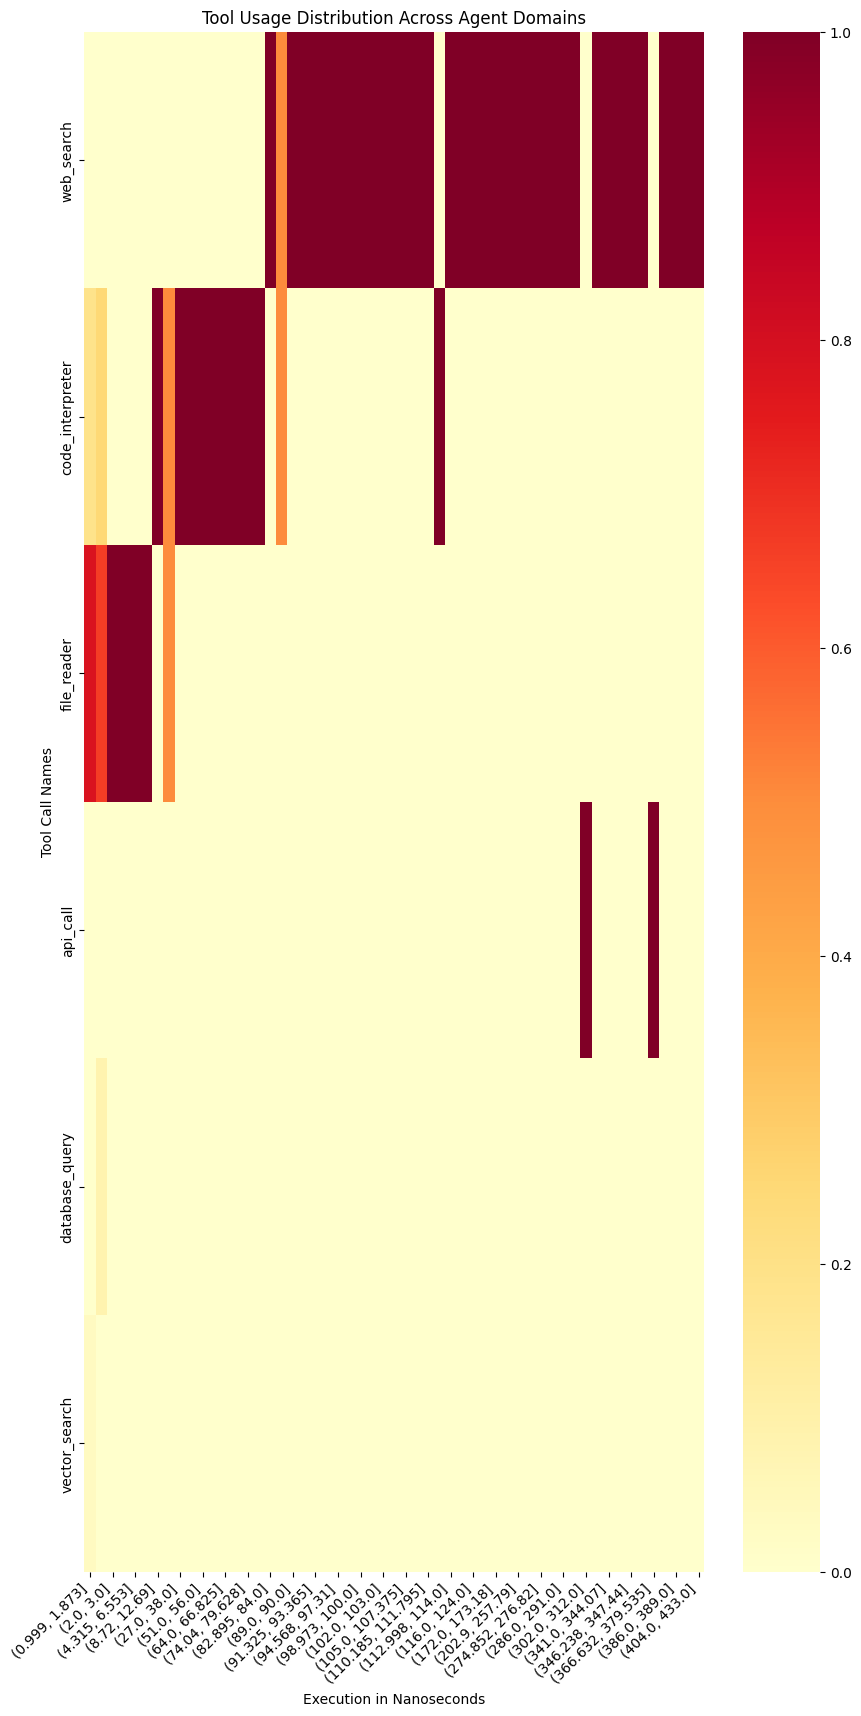

In [7]:
def associate_tool_names(df):
    """Generates a matrix to use within a heatmp visualization.
    
    Explodes tool_name and a target series and casting target to numeric.
    Target is then quantitatively cut into bins for a crosstab tranform for tabular data.
    Finally, the tools are sorted by target for a better visualization and reindexed.
    
    Args:
        df (pd.DataFrame): Cleaned agent latency DataFrame.
    
    Returns:
        ct (pd.crosstab): Transformed matrix for heatmap application.
    """
    target = "latency_ms"
    df = df[df["latency_ms"] > 0].sort_values(by=target)
    tools_exploded = df[["tool_name", target]].explode(target)
    tools_exploded = tools_exploded[tools_exploded[target].notna()]
    tools_exploded[target] = pd.to_numeric(tools_exploded[target])

    tools_exploded["execution_bins"] = pd.qcut(tools_exploded[target], q=400, duplicates="drop")

    ct = pd.crosstab(
        tools_exploded["tool_name"], 
        tools_exploded["execution_bins"], 
        normalize="columns"
    )

    ct = ct.sort_index(axis=1)

    tool_order = (
        tools_exploded.groupby("tool_name")[target]
        .mean()
        .sort_values()
        .index
    )
    
    return ct.reindex(index=tool_order)

tool_matrix = associate_tool_names(df)
tool_matrix = tool_matrix.loc[tool_matrix.sum(axis=1).sort_values(ascending=False).index]
plt.subplots(figsize=(10, 20))
cx = sns.heatmap(tool_matrix, annot=False, fmt=".5f", cmap="YlOrRd")
cx.set_title("Tool Usage Distribution Across Agent Domains")
cx.set_xlabel("Execution in Nanoseconds")
cx.set_ylabel("Tool Call Names")
cx.set_xticklabels(cx.get_xticklabels(), rotation=45, ha="right")

## Hypothesis Test

### Null and Alternative Hypothesis

* H₀: There is no significant difference in mean latency between tool_called and llm_request_sent events.
* H₁: There is a significant difference in mean latency between tool_called and llm_request_sent events.

In [8]:
from scipy.stats import pearson3

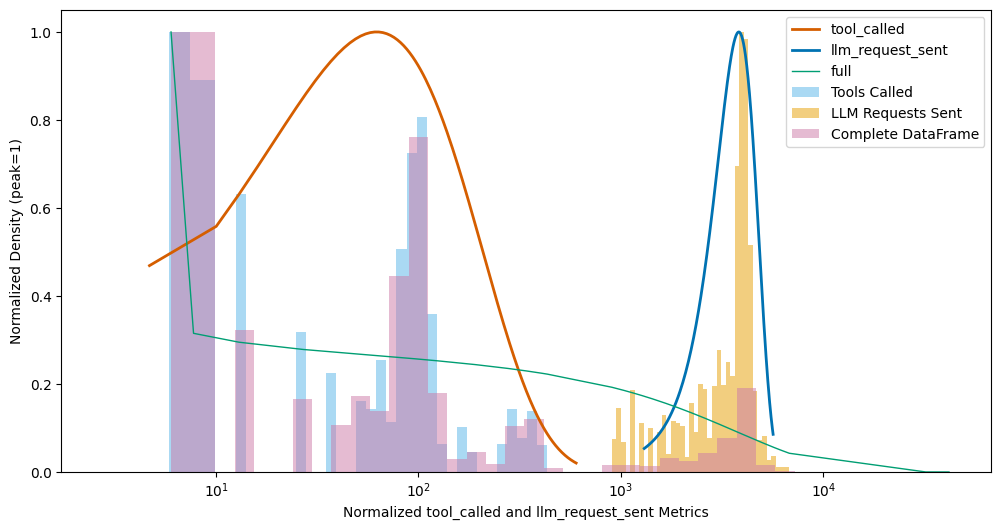

In [30]:
# Whitelist tool calls for latency and filter for (500, 8000)
tool_color = '#D55E00'
llm_color = '#0072B2'
full_color = '#009E73'

tool_hist = '#56B4E9'
llm_hist = '#E69F00'
full_hist = '#CC79A7'

tool_called = "tool_called"
llm_request_sent = "llm_request_sent"
tool_df = df[
    (df['event_type'].isin([tool_called])) & (df['latency_ms'] > 4)
]['latency_ms'].dropna()
llm_df = df[
    (df['event_type'].isin([llm_request_sent])) &
    (df['latency_ms'] < 8000) & (df['latency_ms'] > 500)
]['latency_ms'].dropna()
full_df = df[
    (df['event_type'].isin([llm_request_sent, tool_called])) &
    (df['latency_ms'] > 7)
]['latency_ms'].dropna()
target_df = tool_df

# Fit data latency data to curve
skew, loc, scale = pearson3.fit(target_df)
lskew, lloc, lscale = pearson3.fit(llm_df)
fskew, floc, fscale = pearson3.fit(full_df)
# Generate partitioned data for smooth curve
x = np.linspace(
    # Using 1st and 99th percentile
    pearson3.ppf(0.01, skew, loc=loc, scale=scale),
    pearson3.ppf(0.99, skew, loc=loc, scale=scale),
    200
)
y = np.linspace(
    # Using 1st and 99th percentile
    pearson3.ppf(0.01, lskew, loc=lloc, scale=lscale),
    pearson3.ppf(0.99, lskew, loc=lloc, scale=lscale),
    200
)

def normalize_pdf(target, skew, loc, scale):
    pdf = pearson3.pdf(target, skew, loc=loc, scale=scale)
    return pdf / max(pdf)


fig, ax = plt.subplots(figsize=(12, 6))

# normalizing the histogram: (log(maxima) - log(minima)) / divisor_units
tool_bins = np.logspace(np.log10(target_df.min()), np.log10(target_df.max()), 40)
counts, bin_edges = np.histogram(tool_df, bins=tool_bins, density=True)
counts = counts / counts.max()
ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), alpha=0.5, align='edge', label='Tools Called', color=tool_hist)

llm_bins = np.logspace(np.log10(llm_df.min()), np.log10(llm_df.max()), 40)
lcounts, lbin_edges = np.histogram(llm_df, bins=llm_bins, density=True)
lcounts = lcounts / lcounts.max()
ax.bar(lbin_edges[:-1], lcounts, width=np.diff(lbin_edges), alpha=0.5, align='edge', label='LLM Requests Sent', color=llm_hist)

full_bins = np.logspace(np.log10(full_df.min()), np.log10(full_df.max()), 40)
fcounts, fbin_edges = np.histogram(full_df, bins=full_bins, density=True)
fcounts = fcounts / fcounts.max()
ax.bar(fbin_edges[:-1], fcounts, width=np.diff(fbin_edges), alpha=0.5, align='edge', label='Complete DataFrame', color=full_hist)

random_variate = np.sort(full_df)
ax.plot(x, normalize_pdf(x, skew, loc, scale), tool_color, lw=2, label='tool_called')
ax.plot(y, normalize_pdf(y, lskew, lloc, lscale), llm_color, lw=2, label='llm_request_sent')
ax.plot(random_variate, normalize_pdf(random_variate, fskew, floc, fscale), full_color, lw=1, label='full')

ax.set_xscale('symlog', linthresh=10)
ax.set_xlabel("Normalized tool_called and llm_request_sent Metrics")
ax.set_ylabel("Normalized Density (peak=1)")
ax.legend()

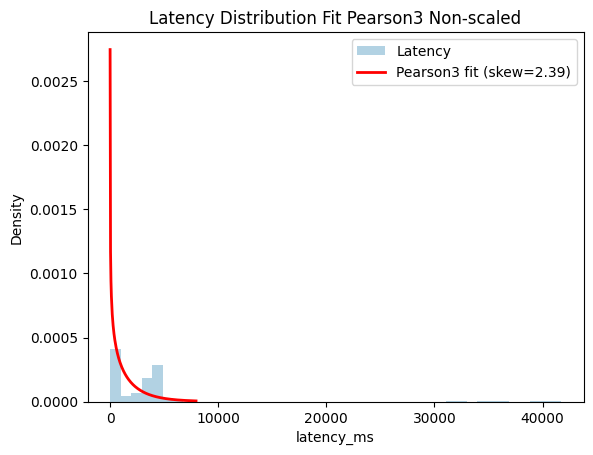

In [32]:
# white_list tool calls for hypothesis testing
whitelist_events = ["tool_called", "llm_request_sent"]
latency_data = df[
    (df['event_type'].isin(whitelist_events)) 
]['latency_ms'].dropna()

# fit the dataframe on pearson3
skew, loc, scale = pearson3.fit(latency_data)

# box the ppf into 200 boxes
x = np.linspace(
    pearson3.ppf(0.01, skew, loc=loc, scale=scale),
    pearson3.ppf(0.99, skew, loc=loc, scale=scale),
    200
)

fig, ax = plt.subplots()
ax.hist(latency_data, bins="auto", density=True, alpha=0.3, label="Latency")
ax.plot(
    x,
    pearson3.pdf(x, skew, loc=loc, scale=scale),
    'r-',
    lw=2,
    label=f'Pearson3 fit (skew={skew:.2f})'
)

ax.set_title("Latency Distribution Fit Pearson3 Non-scaled")
ax.set_xlabel("latency_ms")
ax.set_ylabel("Density")
ax.legend()

plt.show()


6     3358
14    4175
22    4627
30    2007
32    3656
Name: latency_ms, dtype: int64


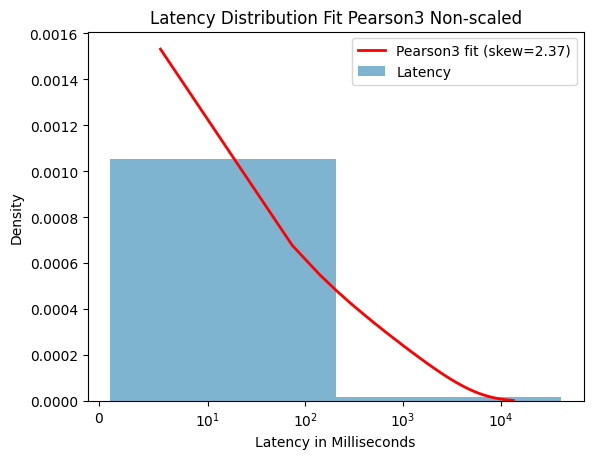

In [33]:
# white_list tool calls for hypothesis testing
whitelist_events = ["tool_called", "llm_request_sent"]
latency_data = df[
    (df['event_type'].isin(whitelist_events)) &
    (df['latency_ms'] > 0)
]['latency_ms'].dropna()
print(latency_data.head())
# fit the dataframe on pearson3
skew, loc, scale = pearson3.fit(latency_data)

# box the ppf into 200 boxes
x = np.linspace(
    pearson3.ppf(0.01, skew, loc=loc, scale=scale),
    pearson3.ppf(0.99, skew, loc=loc, scale=scale),
    200
)

fig, ax = plt.subplots()
# utilize logspace to enforce evenly seperated bins, only 3 here for a simple visual
latency_bins = np.logspace(np.log10(latency_data.min()), np.log10(latency_data.max()), 3)
counts, bin_edges = np.histogram(latency_data, bins=latency_bins, density=True)
ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), alpha=0.5, align='edge',label="Latency")
ax.plot(
    x,
    pearson3.pdf(x, skew, loc=loc, scale=scale),
    'r-',
    lw=2,
    label=f'Pearson3 fit (skew={skew:.2f})'
)
ax.set_xscale('symlog', linthresh=10)
ax.set_title("Latency Distribution Fit Pearson3 Non-scaled")
ax.set_xlabel("Latency in Milliseconds")
ax.set_ylabel("Density")
ax.legend()

plt.show()

In [34]:
r, p = stats.pearsonr(
    df['latency_ms'].dropna(), 
    df['execution_ns'].dropna()
)
print(f"Pearson r: {r:.4f}")
print(f"p-value: {p:.4f}")

Pearson r: 0.4293
p-value: 0.0000
